# DSCI235 Final Project: Music and Mental Health

https://github.com/lerehs/DSCI-235-Final-Project-SP-26

Esha Wick and
Sherel Gonzales
DSCI 235
04/25/2026

### Introduction

data set:

The Music and Mental Health Survey Results posted by Catherine Rasgaitis from the Computer Science department at the University of Washington

We spent a couple of hours together looking through different datasets trying to find something we both had common curiosities about. After scavenging as many pages as kaggle would allow and we were both intrigued at the potential effect of music and mental health. Since we both listen to music and can appreciate the effects we experience personally we figured this would be a great topic to explore. Music plays an important role in many individuals’ lives, motivating our interest in its connection to psychological well-being.

Our project explores the relationship between music listening habits and self-reported mental health. While existing research often examines music’s effects in broad terms, we conduct an exploratory analysis focused on how specific listening behaviors relate to both the presence and severity of mental health conditions. We examine factors such as time spent listening to music, genre preferences, listening context, and familiarity with the language of the music to better understand if these have potential associations with specific mental health as well as overall mental health. 

To do this, we use the Music and Mental Health Survey Results dataset which includes self-reported measures of anxiety, depression, insomnia, and OCD, along with detailed information on music listening habits. Our goal is to identify patterns that can inform future research and generate new questions about how music engagement and mental health are related.

In [83]:
#necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd


### Data exploration and cleaning

As this data is suvery based, we wanted to look at the number of missing values and unique values in each column as good data wrangling practice to maintain awareness of how the data we are working with is presented. 

In [84]:
# different routes for csv file reading in
#s
data = pd.read_csv('/Users/MAC/Desktop/SP 26’/DSCI 235/Jnotebooks/final/mxmh_survey_results.csv')

#e
#data_folder = Path("C:\\Users\\eshaw\\OneDrive\\Desktop\\DataWrangling\\Final Project\\mxmh_survey_results.csv") 
#data = pd.read_csv(data_folder)

#general
#data = pd.read_csv('mxmh_survey_results.csv')


print(data.head())
print(data.info())

            Timestamp   Age Primary streaming service  Hours per day  \
0  8/27/2022 19:29:02  18.0                   Spotify            3.0   
1  8/27/2022 19:57:31  63.0                   Pandora            1.5   
2  8/27/2022 21:28:18  18.0                   Spotify            4.0   
3  8/27/2022 21:40:40  61.0             YouTube Music            2.5   
4  8/27/2022 21:54:47  18.0                   Spotify            4.0   

  While working Instrumentalist Composer         Fav genre Exploratory  \
0           Yes             Yes      Yes             Latin         Yes   
1           Yes              No       No              Rock         Yes   
2            No              No       No  Video game music          No   
3           Yes              No      Yes              Jazz         Yes   
4           Yes              No       No               R&B         Yes   

  Foreign languages  ...  Frequency [R&B]  Frequency [Rap] Frequency [Rock]  \
0               Yes  ...        Sometimes  

In [85]:
for i in data.columns[:-1]:  
    print(i, " : " , data[i].unique())

Timestamp  :  <StringArray>
[ '8/27/2022 19:29:02',  '8/27/2022 19:57:31',  '8/27/2022 21:28:18',
  '8/27/2022 21:40:40',  '8/27/2022 21:54:47',  '8/27/2022 21:56:50',
  '8/27/2022 22:00:29',  '8/27/2022 22:18:59',  '8/27/2022 22:33:05',
  '8/27/2022 22:44:03',
 ...
 '10/23/2022 20:50:27', '10/26/2022 19:45:54',  '10/30/2022 7:24:08',
 '10/30/2022 13:13:32', '10/30/2022 13:15:26', '10/30/2022 14:37:28',
  '11/1/2022 22:26:42',  '11/3/2022 23:24:38',  '11/4/2022 17:31:47',
   '11/9/2022 1:55:20']
Length: 735, dtype: str
Age  :  [18. 63. 61. 21. 19. nan 17. 16. 15. 14. 20. 26. 23. 37. 36. 24. 22. 42.
 25. 32. 29. 41. 31. 33. 30. 43. 28. 34. 13. 35. 27. 53. 49. 60. 38. 44.
 40. 64. 56. 59. 10. 12. 54. 57. 69. 72. 73. 39. 58. 67. 70. 55. 48. 71.
 74. 51. 65. 80. 50. 68. 46. 89.]
Primary streaming service  :  <StringArray>
[                          'Spotify',                           'Pandora',
                     'YouTube Music', 'I do not use a streaming service.',
                    

Our primary dataset for this project contains 32 columns which are:


- Timestamp
When the survey was submitted.


- Age
- Primary Streaming Service
- Hours per day
- While working
Does the respondent listen to music while studying/working?
- Instrumentalist
- Composer
Does the respondent compose music?


- Fav genre
- Exploratory
- Foreign languages


- BPM
Beats per minute of favorite genre


How frequently the respondent listens to [Specific genre]
- Frequency [Classical]
- Frequency [Country]
- Frequency [EDM]  
- Frequency [Folk]
- Frequency [Gospel]   
- Frequency [Hip hop]
- Frequency [Jazz] 
- Frequency [Kpop] 
- Frequency [Latin]
- Frequency [Lofi] 
- Frequency [Metal]    
- Frequency [R&B]  
- Frequency [Rap]  
- Frequency [Rock] 
- Frequency [Video game music] 


Self-reported mental health score, on a scale of 0-10
- Anxiety
- Depression
- Insomnia
- OCD


- Music effects
Does music improve/worsen respondent's mental health conditions?
- Permissions
Permissions to publicize data






We took an exploratory approach for this project and did not do any statistical testing as our data was observational not experimental.


Before comparing effects of music on mental health, we did some analysis on columns such as age and timespan to contextualize the population this data came from. This is a scatterplot of our respondents age:

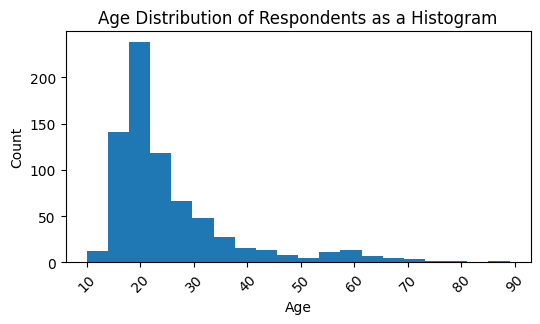

Number of missing values in the Age column: 1
In our dataset, the average age of respondents is 25.206802721088437
The median age of respondents is 21.0
The most common age of respondents is 18.0


In [86]:
# Histogram of age distribution
plt.figure(figsize=(6, 3))
plt.hist(data['Age'], bins = 20)
plt.xticks(rotation=45)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Respondents as a Histogram")
plt.show()

data['Age'].mean()
data['Age'].median()
data['Age'].mode()[0]

#number of nan values in the Age column
print(f"Number of missing values in the Age column: {data['Age'].isna().sum()}")
print(f"In our dataset, the average age of respondents is {data['Age'].mean()}")
print(f"The median age of respondents is {data['Age'].median()}")
print(f"The most common age of respondents is {data['Age'].mode()[0]}")


With our analysis, we want to keep in mind that our respondents are mainly young adults. The data is right skewed meaning there are some respondents from many ages but most respondents are between ages 15 and 35. Only one data point is missing, so the histogram of Age is largely representative of the sample.

We were also curious about when this data was collected so we also made a visualization showing which months the data was gathered in by respondent. 

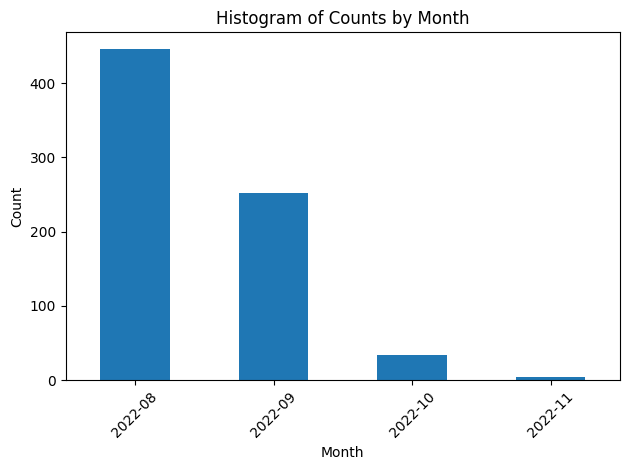

In [87]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])

# Extract year-month (so different years don’t mix)
data['year_month'] = data['Timestamp'].dt.to_period('M')

# Count occurrences per month
monthly_counts = data['year_month'].value_counts().sort_index()

# Plot
monthly_counts.plot(kind='bar')

plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Histogram of Counts by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The data in our primary dataset comes mainly from respondents who submitted their forms in August or September 2022. A few respondents submitted their forms in October and November as well.

Overall, our initial analysis shows most observations are from young adults (respondents aged 18 to 30) and mostly completed in August or September.

A major research focus is based on if there is an affect of mental health based on the time of year. Having data collection be within a shorter timespan can account for any potential seasonal effect. Since the data was collected this way we do not have to controll for the factor of time of year and a focus on young adults and respondents who replied in mainly August should be kept in mind in our exploratory observations.  

We chose not to group data by month since the respondents' timestamps were all within four months of each other and most were within two months of each other. 

As the data has a high count of young adults in 2022, we decided to create a subset of our data with respondents considered young adults, which still encapsulates most of the responses. 

We felt looking at data relative to an age group made sense for our exploratory analysis as we are in this age group and are curious if there are associations between age group and mental health that do not relate to music.

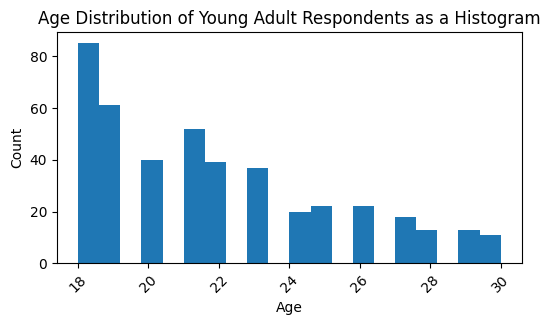

Number of missing values in the Age column: 0
In our young adult dataset, the average age of respondents is 21.82217090069284
The median age of young adultrespondents is 21.0
The most common age of young adult respondents is 18.0

Below is a plot vizualizing the age distribution of young adults compared to all respondents.


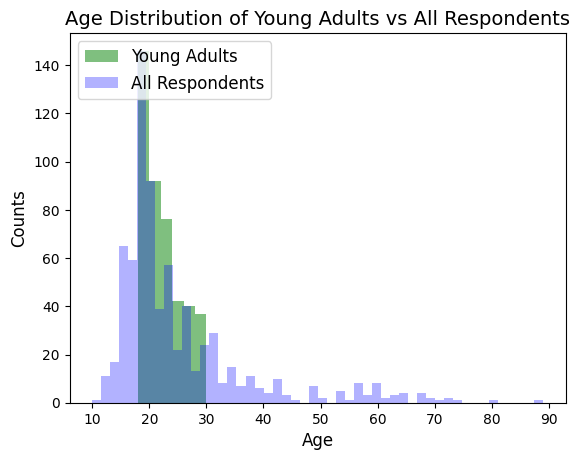

In [88]:
# Young Adults dataframe
df_young_adults = data[(data['Age'] <= 30) & (data['Age'] >= 18)]

# Histogram of Young Adults age distribution
plt.figure(figsize=(6, 3))
plt.hist(df_young_adults['Age'], bins = 20)
plt.xticks(rotation=45)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Young Adult Respondents as a Histogram")
plt.show()

df_young_adults['Age'].mean()
df_young_adults['Age'].median()
df_young_adults['Age'].mode()[0]

#number of nan values in the Age column
print(f"Number of missing values in the Age column: {df_young_adults['Age'].isna().sum()}")
print(f"In our young adult dataset, the average age of respondents is {df_young_adults['Age'].mean()}")
print(f"The median age of young adultrespondents is {df_young_adults['Age'].median()}")
print(f"The most common age of young adult respondents is {df_young_adults['Age'].mode()[0]}\n")

print("Below is a plot vizualizing the age distribution of young adults compared to all respondents.")
x1 = df_young_adults['Age']
x2 = data['Age']

num_bins_young_adult = 6
num_bins_all = 50
plt.hist(x1, num_bins_young_adult, facecolor='green', alpha=0.5, label='Young Adults')
plt.hist(x2, num_bins_all, facecolor='blue', alpha=0.3, label='All Respondents')

plt.xlabel('Age',fontsize=12);
plt.ylabel('Counts', fontsize=12);
plt.title('Age Distribution of Young Adults vs All Respondents', fontsize=14);

plt.legend(loc='upper left', fontsize='12');


Many of the primary streaming services utilized cover a wide variety of genres and allow opportunities to have different listening habits. Our respondents listen to music on the following streaming services:

In [89]:
df_young_adults['Primary streaming service'].unique()

<StringArray>
[                          'Spotify',                     'YouTube Music',
 'I do not use a streaming service.',                       'Apple Music',
           'Other streaming service',                           'Pandora',
                                 nan]
Length: 7, dtype: str

## Exploring Mental Health Conditions in this Dataset
To analyze how music relates to mental health, we first look at which mental disorders we will be focusing on and the severities of those mental disorders. We focus on Anxiety, Depression, Insomnia and OCD because they are some of the most well-known and common mental health disorders. Because this is survey data, we believe self-reported ranks of these disorders could potentially be more reliable for exploratory analysis than self-reported ranks of less well known disorders. These disorders are more commonly known and people may be misinformed on how those disorders present themselves and the symptoms associated with them.

## Exploring the Data

There are four comumns in this dataset which measure mental health with numbers. We created an additional column which averages respondents mental health scores for Anxiety, Depression, Insomnia and OCD.

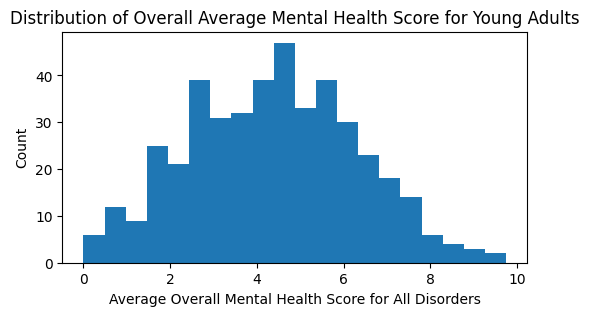

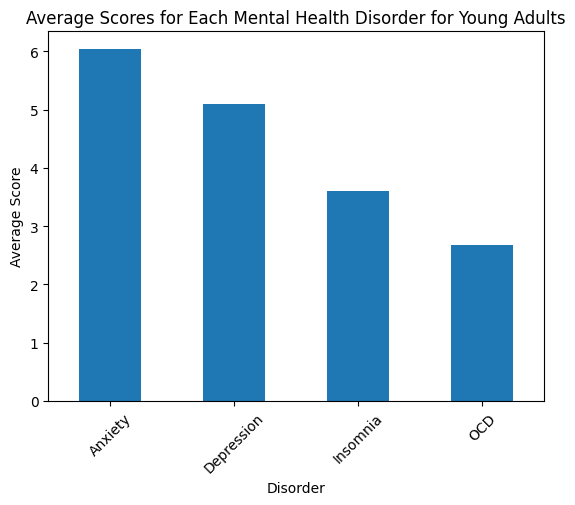

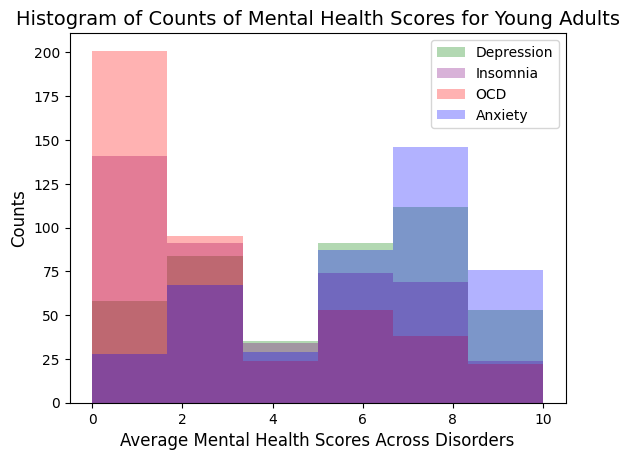

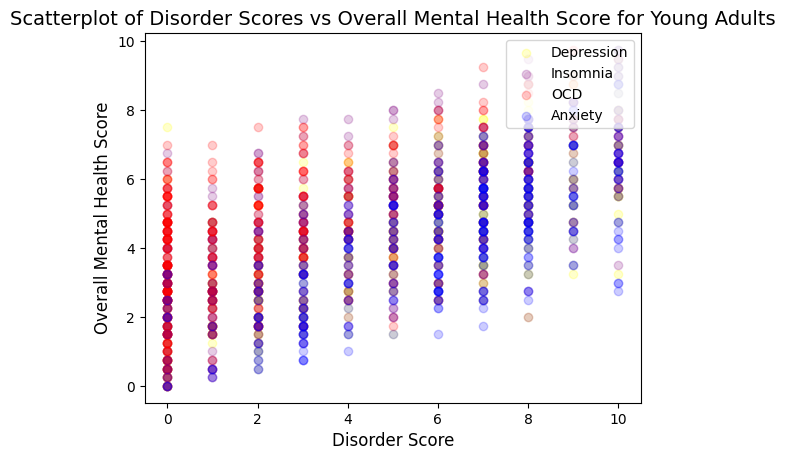

In [90]:
# We use masking to create an average of the Anxiety, Depression, Insomnia and OCD columns for each respondent, 
# and then we plot the distribution of this average score.
df_young_adults['MentalHealthScore'] = df_young_adults[['Anxiety', 'Depression', 'Insomnia', 'OCD']].mean(axis=1) 
plt.figure(figsize=(6, 3))
plt.hist(df_young_adults['MentalHealthScore'], bins=20)
plt.xlabel('Average Overall Mental Health Score for All Disorders')
plt.ylabel('Count')
plt.title('Distribution of Overall Average Mental Health Score for Young Adults')
plt.show()

# Looking at each disorder separately, we calculated the average score for each disorder, and then we plotted these averages in a bar chart.
disorder_means = df_young_adults[['Anxiety', 'Depression', 'Insomnia', 'OCD']].mean()
disorder_means.plot(kind='bar')
plt.xlabel('Disorder')
plt.ylabel('Average Score')
plt.title('Average Scores for Each Mental Health Disorder for Young Adults')
plt.xticks(rotation=45)
plt.show()

# Histogram overlapping the distribution of average mental health scores for all four disorders 
# with the distribution of average mental health scores for young adults only.
x1 = df_young_adults['Anxiety']
x2 = df_young_adults['Depression'] 
x3 = df_young_adults['Insomnia']
x4 = df_young_adults['OCD']

bins = 6
plt.hist(x2, bins, alpha=0.3, label='Depression', color='green')
plt.hist(x3, bins, alpha=0.3, label='Insomnia', color='purple')
plt.hist(x4, bins, alpha=0.3, label='OCD', color='red')
plt.hist(x1, bins, alpha=0.3, label='Anxiety', color='blue')


plt.xlabel('Average Mental Health Scores Across Disorders',fontsize=12);
plt.ylabel('Counts', fontsize=12);
plt.title('Histogram of Counts of Mental Health Scores for Young Adults', fontsize=14);

plt.legend(loc='upper right', fontsize='10');
plt.show()

#Scatterplot overlapping the distribution of average mental health scores for all four disorders
# with the distribution of average mental health scores for young adults only.
x1 = df_young_adults['Anxiety']
x2 = df_young_adults['Depression'] 
x3 = df_young_adults['Insomnia']
x4 = df_young_adults['OCD']

# Overall mental health score (mean of all four)
overall = (x1 + x2 + x3 + x4) / 4

plt.scatter(x2, overall, alpha=0.2, label='Depression', color='yellow')
plt.scatter(x3, overall, alpha=0.2, label='Insomnia', color='purple')
plt.scatter(x4, overall, alpha=0.2, label='OCD', color='red')
plt.scatter(x1, overall, alpha=0.2, label='Anxiety', color='blue')

plt.ylabel('Overall Mental Health Score', fontsize=12)
plt.xlabel('Disorder Score', fontsize=12)
plt.title('Scatterplot of Disorder Scores vs Overall Mental Health Score for Young Adults', fontsize=14)

plt.legend(loc='upper right', fontsize=10)



In [91]:
print(df_young_adults['MentalHealthScore'].mean())
print(df_young_adults['MentalHealthScore'].median())
print(df_young_adults['MentalHealthScore'].mode()[0])

print(f"The mean anxiety score is: {df_young_adults['Anxiety'].mean()}")
print(f"The mean depression score is: {df_young_adults['Depression'].mean()}")
print(f"The mean insomnia score is: {df_young_adults['Insomnia'].mean()}")
print(f"The mean OCD score is: {df_young_adults['OCD'].mean()}")

4.356812933025404
4.5
4.5
The mean anxiety score is: 6.0392609699769055
The mean depression score is: 5.1016166281755195
The mean insomnia score is: 3.602771362586605
The mean OCD score is: 2.6836027713625867


## Assessing plots


Mental health scores are on a sliding scale from 0 to 10.


Please note that scores of 0 mean respondents do not experience this and scores of 10 indicate they experience this regularly, constantly/or to an extreme. 


Looking at these plots and statistics, most people in our dataset had an overall mental health score, which was calculated by averaging their mental health scores across disorders, of 4.5. This was also the median mental health score. The mean was slightly lower, indicating the data is slightly right skewed.


Anxiety and Depression had means much higher than the mean of respondents overall mental health scores among young adults. OCD had low scores, indicating more people surveyed suffer from severe Anxiety and Depression than OCD. Insomnia was somewhat in the middle of Depression and OCD.


## Exploring Listening Habits


Genre diversity scores are calculated by counting the number of genres for which a respondent listens "Sometimes" or "Very frequently".
The average genre diversity score is: 6.124711316397229
The maximum genre diversity score is: 16
The minimum genre diversity score is: 0


Text(0.5, 1.0, 'Genre Diversity vs. Overall Mental Health Score for Young Adults')

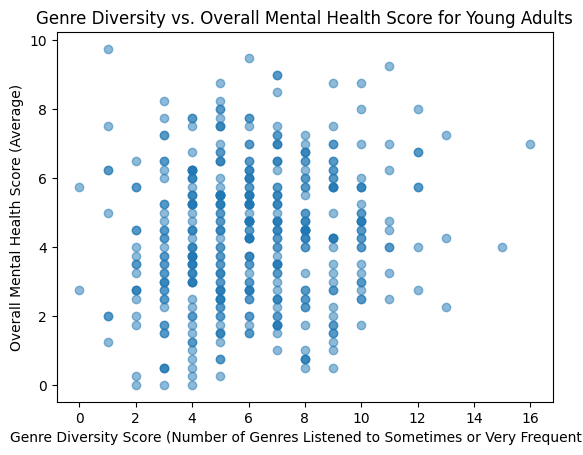

In [92]:
df = df_young_adults.copy()

freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Very frequently": 3
}

genre_cols = [
    'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
    'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]',
    'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]',
    'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]'
]

# Map the values
df[genre_cols] = df[genre_cols].apply(lambda x: x.map(freq_map))

df['genre_diversity'] = df[genre_cols].apply(lambda row: (row >= 2).sum(), axis=1)

print('Genre diversity scores are calculated by counting the number of genres for which a respondent listens "Sometimes" or "Very frequently".')
print(f'The average genre diversity score is: {df["genre_diversity"].mean()}')
print(f'The maximum genre diversity score is: {df["genre_diversity"].max()}')
print(f'The minimum genre diversity score is: {df["genre_diversity"].min()}')

# Scatterplot of genre diversity vs. overall mental health score
plt.scatter(df['genre_diversity'], df['MentalHealthScore'], alpha=0.5)
plt.xlabel('Genre Diversity Score (Number of Genres Listened to Sometimes or Very Frequently)')
plt.ylabel('Overall Mental Health Score (Average)')
plt.title('Genre Diversity vs. Overall Mental Health Score for Young Adults')

Genre diversity and overall mental health do not appear to have an obvious possible association with each other. 

In [93]:
df['Exploratory_bool'] = df['Exploratory'].map({'Yes': True, 'No': False}).fillna(False)
df['Foreign_bool'] = df['Foreign languages'].map({'Yes': True, 'No': False}).fillna(False)

# Aggregate means and group counts
exploratory_foreign = df.groupby(['Exploratory_bool', 'Foreign_bool'])[['Anxiety', 'Depression', 'Insomnia', 'OCD', 'MentalHealthScore']].mean().reset_index()
exploratory_foreign['Count'] = df.groupby(['Exploratory_bool', 'Foreign_bool'])['MentalHealthScore'].size().values
exploratory_foreign['Percent'] = (df.groupby(['Exploratory_bool', 'Foreign_bool']).size().values / len(df) * 100).round(2)
exploratory_foreign['Percent'] = exploratory_foreign['Percent'].map(lambda x: f'{x:.2f}')

# For disorder-level percents, compute counts among respondents with score >= 6,
# reindex to match the group order and divide by total respondents
anxiety_counts = df[df['Anxiety'] >= 6].groupby(['Exploratory_bool', 'Foreign_bool']).size()
depression_counts = df[df['Depression'] >= 6].groupby(['Exploratory_bool', 'Foreign_bool']).size()
insomnia_counts = df[df['Insomnia'] >= 6].groupby(['Exploratory_bool', 'Foreign_bool']).size()
ocd_counts = df[df['OCD'] >= 6].groupby(['Exploratory_bool', 'Foreign_bool']).size()

idx = exploratory_foreign.set_index(['Exploratory_bool', 'Foreign_bool']).index
exploratory_foreign['Anxiety Percent'] = (anxiety_counts.reindex(idx, fill_value=0).values / anxiety_counts.sum() * 100).round(2)
exploratory_foreign['Depression Percent'] = (depression_counts.reindex(idx, fill_value=0).values / depression_counts.sum() * 100).round(2)
exploratory_foreign['Insomnia Percent'] = (insomnia_counts.reindex(idx, fill_value=0).values / insomnia_counts.sum() * 100).round(2)
exploratory_foreign['OCD Percent'] = (ocd_counts.reindex(idx, fill_value=0).values / ocd_counts.sum() * 100).round(2)

exploratory_foreign

,Exploratory_bool,Foreign_bool,Anxiety,Depression,Insomnia,OCD,MentalHealthScore,Count,Percent,Anxiety Percent,Depression Percent,Insomnia Percent,OCD Percent
0,False,False,5.754098,4.868852,2.655738,2.508197,3.946721,61,14.09,12.36,13.18,7.63,9.76
1,False,True,6.358491,4.905660,3.396226,2.962264,4.405660,53,12.24,13.09,10.45,11.45,15.85
2,True,False,5.903509,4.885965,3.614035,3.052632,4.364035,114,26.33,25.09,24.09,24.43,35.37
3,True,True,6.117073,5.341463,3.931707,2.458537,4.462195,205,47.34,49.45,52.27,56.49,39.02


There are no obvious trends between being an exploratory and or foreign language listener to mental health scores. If anything, most or many people seem to be exploratory listeners who listen to music in foreign languages.

In [94]:
df = df_young_adults.copy()

freq_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Very frequently": 3
}

insomnia = df[df['Insomnia'] >= 6]

genre_cols = [
    'Frequency [Classical]', 'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
    'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]', 'Frequency [K pop]',
    'Frequency [Latin]', 'Frequency [Lofi]', 'Frequency [Metal]', 'Frequency [Pop]',
    'Frequency [R&B]', 'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]'
]

insomnia[genre_cols] = insomnia[genre_cols].apply(lambda x: x.map(freq_map))
df[genre_cols] = df[genre_cols].apply(lambda x: x.map(freq_map))

print(f"Mean Anxiety score for insomnia group: {insomnia['Anxiety'].mean()}")
print(f"Mean Depression score for insomnia group: {insomnia['Depression'].mean()}")
print(f"Mean OCD score for insomnia group: {insomnia['OCD'].mean()}")

Mean Anxiety score for insomnia group: 7.00763358778626
Mean Depression score for insomnia group: 6.549618320610687
Mean OCD score for insomnia group: 3.3587786259541983


Among respondents who report high levels of insomnia, average Anxiety and Depression scores are roughly two times higher than averages for all respondents. There may be an association between having anxiety and having insomnia. There may also be an association between having depression and insomnia.

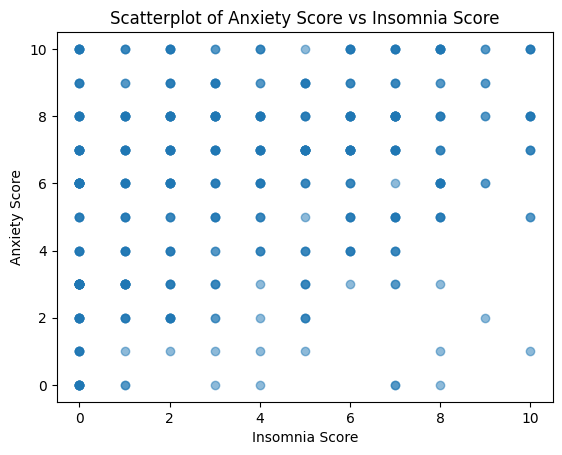

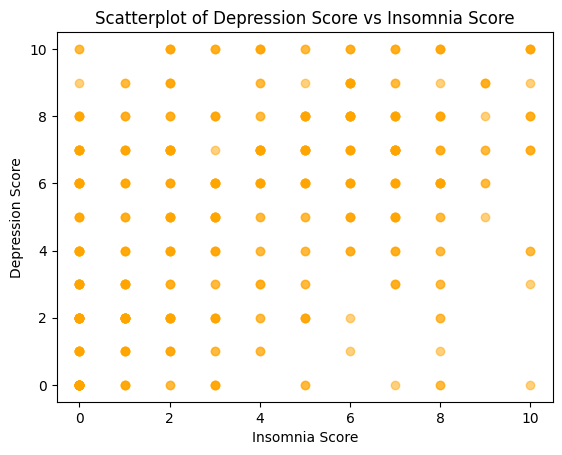

In [95]:
# Scatterplot of people with Anxiety Score versus Insomnia Score
plt.scatter(df['Insomnia'], df['Anxiety'], alpha=0.5)
plt.xlabel('Insomnia Score')
plt.ylabel('Anxiety Score')
plt.title('Scatterplot of Anxiety Score vs Insomnia Score')
plt.show()

# Scatterplot of people with Depression Score versus Insomnia Score
plt.scatter(df['Insomnia'], df['Depression'], alpha=0.5, color='orange')
plt.xlabel('Insomnia Score')
plt.ylabel('Depression Score')
plt.title('Scatterplot of Depression Score vs Insomnia Score')
plt.show()

In [96]:
# Identifying if insomnia is more likely to be associated with listening to calming music genres like classical, folk, or lofi.
calming_genres = ['Frequency [Classical]', 'Frequency [Folk]', 'Frequency [Lofi]']
no_insomnia = df[df['Insomnia'] < 6]
insomnia = df[df['Insomnia'] >= 6]

print("Comparing mean scores for calming genres between insomnia and no insomnia groups:\nScores are on a scale from 0 to 3, where 0 = Never, 1 = Rarely, 2 = Sometimes, and 3 = Very frequently.\n")

for genre in calming_genres:
    mean_score = insomnia[genre].mean()
    mean_score_no_insomnia = no_insomnia[genre].mean()

    print(f"Mean {genre} score for insomnia group: {mean_score}")
    print(f"Mean {genre} score for no insomnia group: {mean_score_no_insomnia}")
    print(f'Difference in mean {genre} score between insomnia and no insomnia groups: {mean_score - mean_score_no_insomnia}\n')

Comparing mean scores for calming genres between insomnia and no insomnia groups:
Scores are on a scale from 0 to 3, where 0 = Never, 1 = Rarely, 2 = Sometimes, and 3 = Very frequently.

Mean Frequency [Classical] score for insomnia group: 1.3587786259541985
Mean Frequency [Classical] score for no insomnia group: 1.2019867549668874
Difference in mean Frequency [Classical] score between insomnia and no insomnia groups: 0.15679187098731107

Mean Frequency [Folk] score for insomnia group: 1.1603053435114503
Mean Frequency [Folk] score for no insomnia group: 1.0198675496688743
Difference in mean Frequency [Folk] score between insomnia and no insomnia groups: 0.14043779384257604

Mean Frequency [Lofi] score for insomnia group: 1.297709923664122
Mean Frequency [Lofi] score for no insomnia group: 1.1059602649006623
Difference in mean Frequency [Lofi] score between insomnia and no insomnia groups: 0.19174965876345973



On average, people with insomnia appear to possibly listen to calming genres such as Classical, Folk and Lofi slightly more than people without high levels of insomnia. However they still do not listen to these genres very frequently.

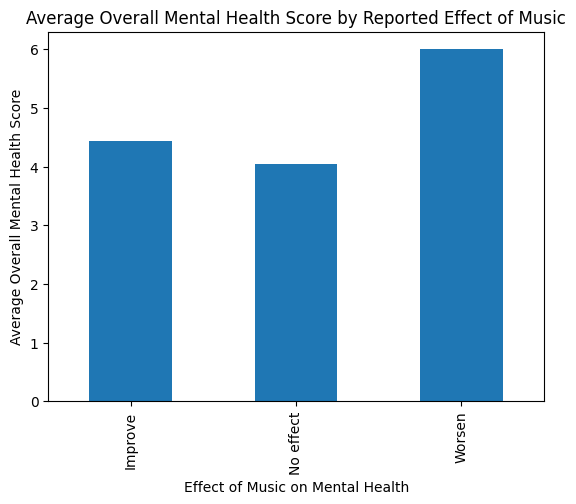

Music effects,Improve,No effect,Worsen
MentalHealthScore,,,
0.00,1.0,2.0,NaN
0.25,2.0,1.0,NaN
0.50,3.0,2.0,NaN
0.75,6.0,NaN,NaN
1.00,2.0,1.0,NaN
1.25,3.0,2.0,NaN
1.50,7.0,4.0,NaN
1.75,8.0,5.0,NaN
2.00,10.0,2.0,NaN


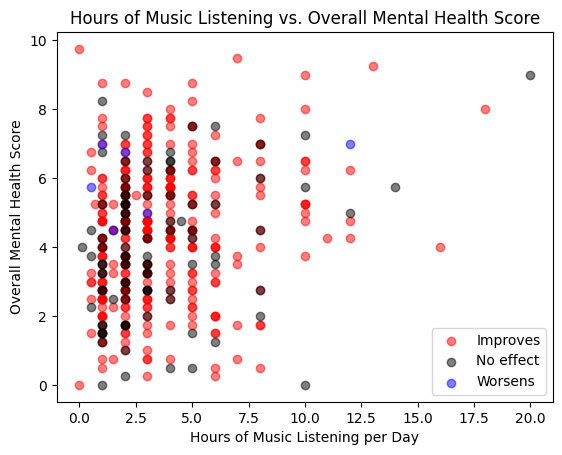

<StringArray>
[nan, 'No effect', 'Improve', 'Worsen']
Length: 4, dtype: str

In [97]:
#Scatterplot: Music imporve repsondents mental heaslth versus hours per day listened
#Hours per day and severity of mental health score

df_young_adults['Music effects'].unique()

mental_effects = df_young_adults.groupby('Music effects')[['MentalHealthScore']].mean().reset_index()
mental_effects.plot(kind='bar', x='Music effects', y='MentalHealthScore', legend=False)
plt.xlabel('Effect of Music on Mental Health')
plt.ylabel('Average Overall Mental Health Score')
plt.title('Average Overall Mental Health Score by Reported Effect of Music')
plt.show()

todisplay = df_young_adults.pivot_table(
    index='MentalHealthScore',
    columns='Music effects',
    aggfunc='size'
)
display(todisplay)


df_improve = df_young_adults[df_young_adults['Music effects'] == 'Improve']
df_no_effect = df_young_adults[df_young_adults['Music effects'] == 'No effect']
df_worsens = df_young_adults[df_young_adults['Music effects'] == 'Worsen']

plt.scatter(df_improve['Hours per day'], df_improve['MentalHealthScore'], alpha=0.5, label='Improves', color='red')
plt.scatter(df_no_effect['Hours per day'], df_no_effect['MentalHealthScore'], alpha=0.5, label='No effect', color='black')
plt.scatter(df_worsens['Hours per day'], df_worsens['MentalHealthScore'], alpha=0.5, label='Worsens', color='blue')

plt.xlabel('Hours of Music Listening per Day')
plt.ylabel('Overall Mental Health Score')
plt.title('Hours of Music Listening vs. Overall Mental Health Score')
plt.legend()
plt.show()
df_improve
df_young_adults['Music effects'].unique()



In [98]:
df_young_adults.pivot_table(
    index='Fav genre',
    columns='Music effects',
    aggfunc='size',
    fill_value=0
)

Music effects,Improve,No effect,Worsen
Fav genre,,,
Classical,12,7,0
Country,13,4,0
EDM,23,3,0
Folk,13,4,0
Gospel,1,0,0
Hip hop,18,3,0
Jazz,11,3,0
K pop,13,2,0
Latin,1,0,0


Feeling like music worsens, improves or does not appear to affect one's mental health and does not appear to have a very strong relationship with any relationship with respondents overall mental health. We observe that increasing mental health score does not appear to be correlated with how music affects a person's mental health.


That said, it appears that people think music affects them more than it does. There may be an inflated expectation on the impact of music on mental health.


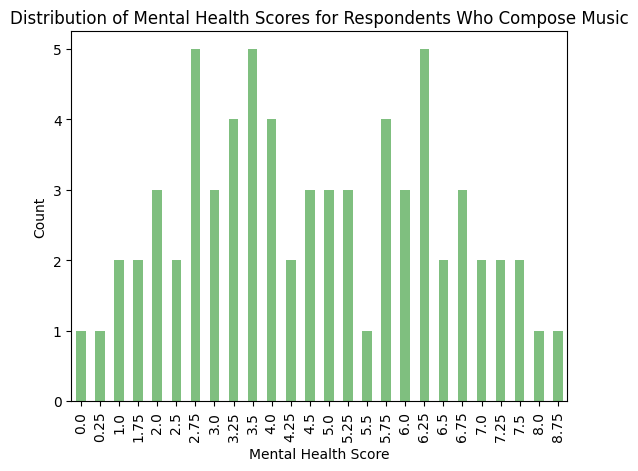

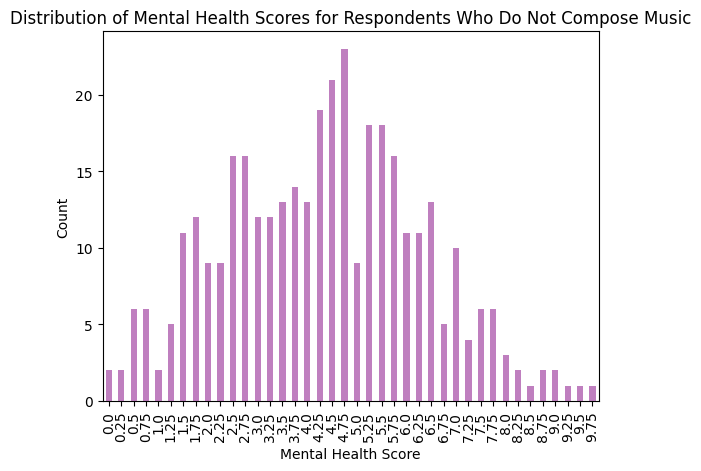

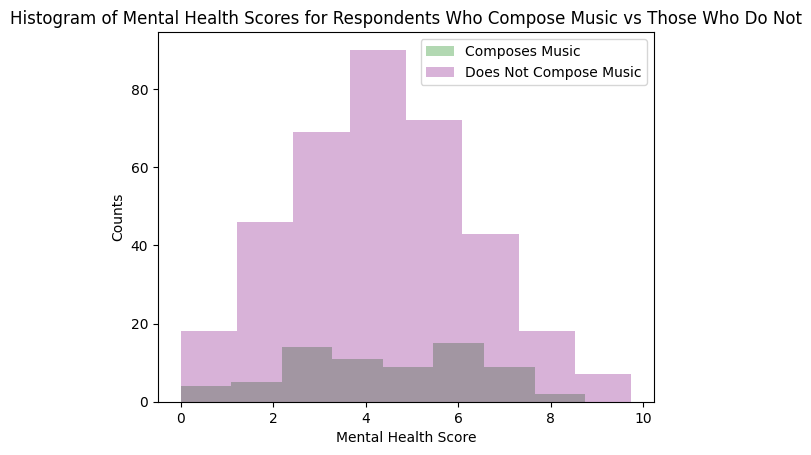

Average mental health score for respondents who compose music: 4.492753623188406
Average mental health score for respondents who do not compose music: 4.3319559228650135
For respondents who compose music, the distribution of mental health scores is shown in the first bar chart. 
For respondents who do not compose music, the distribution of mental health scores is shown in the second bar chart.
Average mental health score for respondents who compose music: 4.492753623188406
Average mental health score for respondents who do not compose music: 4.3319559228650135


In [99]:
# Bar chart hours per day versus while working
yes_scores = df_young_adults[df_young_adults['Composer'] == 'Yes']['MentalHealthScore']
no_scores = df_young_adults[df_young_adults['Composer'] == 'No']['MentalHealthScore']

yes_counts = yes_scores.value_counts().sort_index()
yes_counts.plot(kind='bar', orientation='vertical', color='green', alpha=0.5)
plt.xlabel('Mental Health Score')
plt.ylabel('Count')
plt.title('Distribution of Mental Health Scores for Respondents Who Compose Music')
plt.show()

no_counts = no_scores.value_counts().sort_index()
no_counts.plot(kind='bar', orientation='vertical', color='purple', alpha=0.5)
plt.xlabel('Mental Health Score')
plt.ylabel('Count')
plt.title('Distribution of Mental Health Scores for Respondents Who Do Not Compose Music')
plt.show()

bins = 8
plt.hist(yes_scores, bins, alpha=0.3, label='Composes Music', color='green')
plt.hist(no_scores, bins, alpha=0.3, label='Does Not Compose Music', color='purple')


plt.xlabel('Mental Health Score');
plt.ylabel('Counts');
plt.title('Histogram of Mental Health Scores for Respondents Who Compose Music vs Those Who Do Not');

plt.legend(loc='upper right');
plt.show()

print("Average mental health score for respondents who compose music:", yes_scores.mean())
print("Average mental health score for respondents who do not compose music:", no_scores.mean())
print("For respondents who compose music, the distribution of mental health scores is shown in the first bar chart. \nFor respondents who do not compose music, the distribution of mental health scores is shown in the second bar chart.")

print("Average mental health score for respondents who compose music:", yes_scores.mean())
print("Average mental health score for respondents who do not compose music:", no_scores.mean())


Next, we will look at if playing an instrument is related to overall mental health score. 

/var/folders/b6/v9g8x_7n61bgb3hydxctf44r0000gn/T/ipykernel_19131/893893653.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([instrumentalists, non_instrumentalists], labels=['Instrumentalists', 'Non-Instrumentalists'])


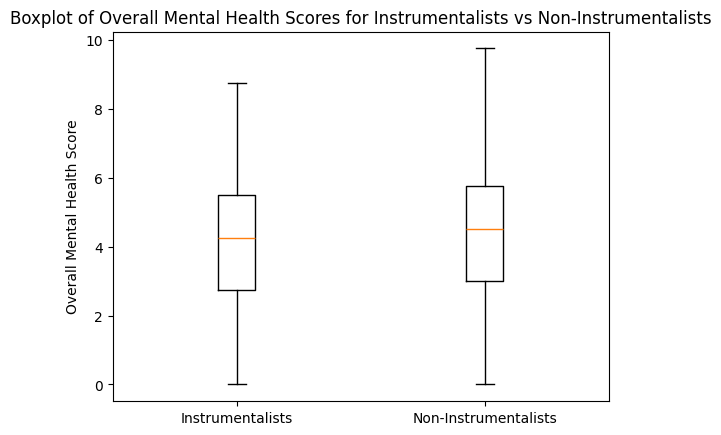

In [100]:
# Boxplot of mental health scores for instrumentalists vs non-instrumentalists
instrumentalists = df_young_adults[df_young_adults['Instrumentalist'] == 'Yes']['MentalHealthScore']
non_instrumentalists = df_young_adults[df_young_adults['Instrumentalist'] == 'No']['MentalHealthScore']
plt.boxplot([instrumentalists, non_instrumentalists], labels=['Instrumentalists', 'Non-Instrumentalists'])
plt.ylabel('Overall Mental Health Score')
plt.title('Boxplot of Overall Mental Health Scores for Instrumentalists vs Non-Instrumentalists')
plt.show()

There does not appear to be a large difference in mental health of instrumentalists and non instrumentalists in this boxplot. Non-instrumentalists appear to have a slightly larger range of mental health scores, however, it is not by much. The plots look very similar.


We noted that the majority of people in this sample claimed music "Improved" their mental health, however, mental health scores have not appeared to be associated with most if any of the musical factors this analysis has looked at.

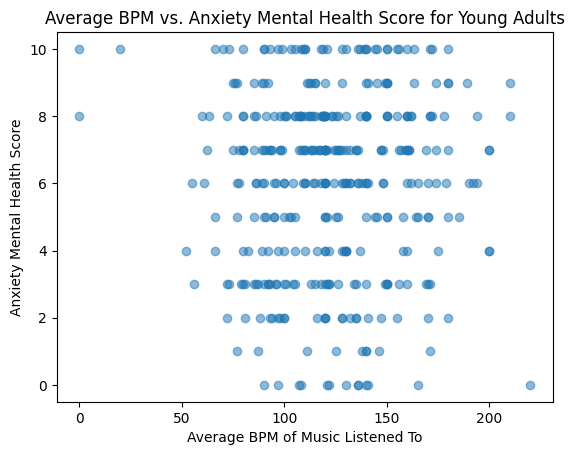

The average BPM of music listened to by young adults in our dataset is: 122.50806451612904
Looking at the scatterplot, there does not appear to be a strong relationship between the average BPM of music listened to 
and the Anxiety score for young adults in our dataset. However, further statistical analysis would be needed to confirm this observation.


In [101]:
BPM_average = df_young_adults['BPM'].mean()
BPM_average

# Scatterplot of BPM versus overall mental health score
plt.scatter(df_young_adults['BPM'], df_young_adults['Anxiety'], alpha=0.5)
plt.xlabel('Average BPM of Music Listened To')
plt.ylabel('Anxiety Mental Health Score')
plt.title('Average BPM vs. Anxiety Mental Health Score for Young Adults')
plt.show()

print("The average BPM of music listened to by young adults in our dataset is:", BPM_average)
print("Looking at the scatterplot, there does not appear to be a strong relationship between the average BPM of music listened to \nand the Anxiety score for young adults in our dataset. However, further statistical analysis would be needed to confirm this observation.")

#Comparing exploratory and foreign langauges
# Do people who consider themselves to be more exploratory in their music taste listen to foreign music more?
df_young_adults['Exploratory'] = df_young_adults['Exploratory'].map({'Yes': 1, 'No': 0})
df_young_adults['Foreign languages'] = df_young_adults['Foreign languages'].map({'Yes': 1, 'No': 0})
# Use xs

### Conclusion


Starting this project, we anticipated seeing associations between listening habits, musical preferences and mental health disorder scores. After completing the exploratory analysis, however, we failed to find any strong associations between music listening habits and mental health scores. This contrasts the survey's respondents overwhelmingly claiming music helps their mental health and provides questions as to the perception of music on mental health versus the actuality of how music affects one's mental health.


We are still curious about how other factors could have affected our analysis. If we had recurrent responses from the same respondents throughout the year we could assess for differences throughout the year. To try and discover any correlation between music with a factor of season on mental health. 


Even though our research did not lead us to the significance we had hoped for, we are still satisfied by being able to gain practice with a dataset and thinking over how an experiment/ data collection could be better. Which are skills we both are hoping to strengthen and hone.   
